In [1]:
# Load libraries
import pandas as pd
from mbiomekit.group_comparison import analysis, plotter

In [2]:
# Load data
ft = pd.read_csv('data/ft_genus_prv01.tsv', sep='\t', header=0, index_col=0)
group = pd.read_csv('data/group.tsv', sep='\t', header=0, index_col=0)
ent = pd.read_csv('data/enterotype.tsv', sep='\t', header=0, index_col=0)

In [3]:
# enterotype grouping
id_c0 = ent.index[ent['cluster'] == 0]
id_c1 = ent.index[ent['cluster'] == 1]
id_c2 = ent.index[ent['cluster'] == 2]
id_c3 = ent.index[ent['cluster'] == 3]

ids = {0: id_c0,
       1: id_c1,
       2: id_c2,
       3: id_c3}

grp_map = {}
for sid, g in group['group1'].items():
    grp_map[sid] = g

In [4]:
# parameters
palette = {'Healthy': '#aaadb2',
           'Prevent': '#9fbcca',
           'Predict': '#326a81'}

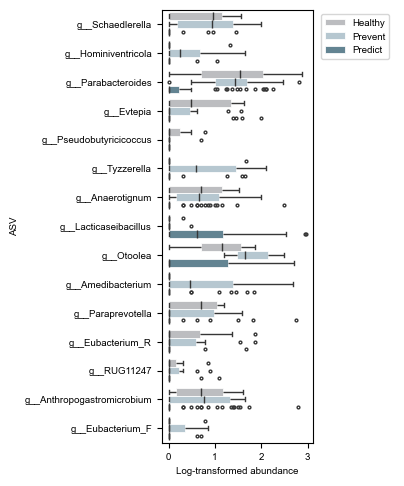

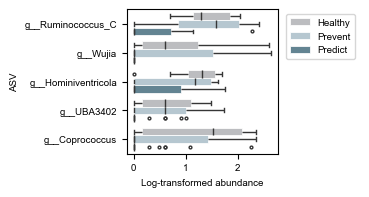

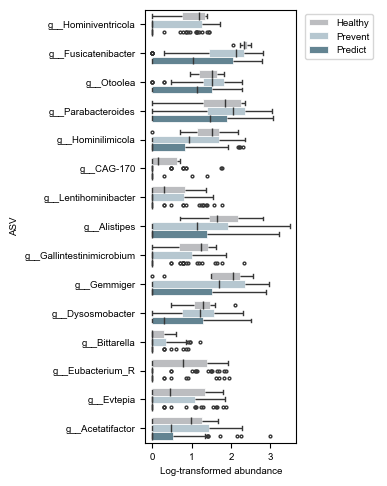

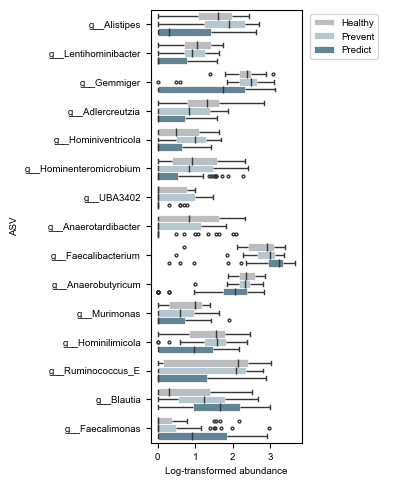

In [5]:
for c in ids:    
    an = analysis.Analyzer()
    an.set_feature_table(ft.loc[:, ids[c]])
    an.set_group(group.loc[ids[c], 'group1'])
    an.group_analysis()
    an.save_results(f'data/3-results/group_comparison/kruskal_cl{c}_genus.tsv', f'data/3-results/group_comparison/dunn_cl{c}_genus.json')
    
    id_sel = an.result_kruskal.index[an.result_kruskal['adjusted-p'] < 0.05][:15]
    ft_sel = ft.loc[id_sel, ids[c]]

    pt = plotter.Plotter()
    pt.plot_microbe_abundance(ft_sel, fout=f'figures/group_comparison/top15_da_genus_cl{c}.pdf', palette=palette, group_map=grp_map, label='ASV', hue_order=['Healthy', 'Prevent', 'Predict'])
